# HMM5 — HMM2 + features de vegetación + horas de luz diarias

Variante de `HMM2.ipynb` que **añade tres features** al espacio de observaciones:

- `veg_low` ∈ [0, 1] — cobertura de vegetación baja (ECMWF Interim).
- `veg_high` ∈ [0, 1] — cobertura de vegetación alta (ECMWF Interim).
- `horas_luz` ∈ [0, 24] — horas de luz astronómicas en el día y la latitud del ave.

Todo lo demás se mantiene idéntico a HMM2: `lengths=` por `trayectoria_id`, 15 inicializaciones aleatorias, `covariance_type='diag'`, asignación 0/1 automática por `means_`, sin escalar features.

**Hipótesis biológica**: la fotoperiodía es un disparador conocido del comportamiento migratorio en aves; en latitudes altas el sol de medianoche permite vuelos prolongados y en invierno boreal los días cortos limitan la actividad diurna. Si la fotoperiodía discrimina estados, debería aparecer una diferencia clara en la media de `horas_luz` entre los dos estados aprendidos.

**Predicción a priori**: con `step_length` con varianza ~10⁴ km², el HMM se sigue enganchando a la velocidad. Las nuevas features tienen varianza mucho menor (vegetación ~0,1; horas_luz ~10–50), así que el efecto en la frontera será pequeño. Lo medimos con BIC, concordancia día-a-día contra HMM2 y diferencia de medias por estado.

Convención: `0 = migración`, `1 = estacionario`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1. Carga del CSV limpio

Entrada: `data/processed/aves_procesado_markov.csv` (1 fila/(ave, día) hacia las 14h, segmentos continuos por `trayectoria_id`).

In [2]:
df = pd.read_csv('../data/processed/aves_procesado_markov.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['trayectoria_id', 'date']).reset_index(drop=True)

print(f'Filas: {len(df):,}')
print(f'Aves únicas: {df["animal_id"].nunique()}')
print(f'Trayectorias: {df["trayectoria_id"].nunique()}')
print(f'Rango temporal: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Filas: 22,041
Aves únicas: 117
Trayectorias: 480
Rango temporal: 2009-05-25 → 2015-08-23


,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id
0,91732A,2010-04-18,14,32.6790,29.1823,0.0032,0.0001,91732A_Seg10
1,91732A,2010-04-19,14,32.5083,29.8573,0.0114,0.0006,91732A_Seg10
2,91732A,2010-04-20,14,32.4677,29.9302,0.0131,0.0007,91732A_Seg10
3,91732A,2010-04-21,14,32.4933,29.8072,0.0112,0.0006,91732A_Seg10
4,91732A,2010-04-22,14,32.4782,29.9287,0.0128,0.0007,91732A_Seg10


## 2. Features de movimiento

Idéntico a HMM2: para cada `trayectoria_id` calculamos `step_length` (km, haversine), `bearing` (grados, great-circle) y `turning_angle` (radianes, normalizado a [-π, π]).

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia haversine entre dos puntos (lat, lon) en grados, en km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def calculate_bearing(lat1, lon1, lat2, lon2):
    """Rumbo great-circle inicial en grados [0, 360); 0=norte, sentido horario."""
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlambda = np.radians(lon2 - lon1)
    y = np.sin(dlambda) * np.cos(phi2)
    x = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlambda)
    return (np.degrees(np.arctan2(y, x)) + 360) % 360

In [4]:
df['next_lat'] = df.groupby('trayectoria_id')['lat'].shift(-1)
df['next_lon'] = df.groupby('trayectoria_id')['lon'].shift(-1)

df['step_length'] = haversine_km(df['lat'], df['lon'], df['next_lat'], df['next_lon'])
df['bearing'] = calculate_bearing(df['lat'], df['lon'], df['next_lat'], df['next_lon'])

delta_bearing = df.groupby('trayectoria_id')['bearing'].diff()
df['turning_angle'] = np.arctan2(
    np.sin(np.radians(delta_bearing)),
    np.cos(np.radians(delta_bearing)),
)

print('NaNs por columna (esperados: última fila/trayectoria sin step, primera sin turning):')
print(df[['step_length', 'bearing', 'turning_angle']].isna().sum())

NaNs por columna (esperados: última fila/trayectoria sin step, primera sin turning):
step_length      480
bearing          480
turning_angle    960
dtype: int64


## 3. Horas de luz diarias (nueva feature)

Calculamos las horas de luz astronómicas (centro del sol en el horizonte) para cada (latitud, día del año) usando la fórmula clásica del ángulo horario solar con la declinación de Spencer (1971):

$$\delta = 0{,}006918 - 0{,}399912\cos P + 0{,}070257\sin P - 0{,}006758\cos 2P + \ldots$$

donde $P = 2\pi (N-1)/365$ y $N$ es el día del año. El ángulo horario al amanecer es $\omega_0 = \arccos(-\tan\varphi \tan\delta)$ y la duración del día es $24/\pi \cdot \omega_0$ horas.

**Casos polares**: cuando $|\tan\varphi \tan\delta| > 1$ no hay puesta o no hay salida del sol; el clipping convierte estas situaciones en 0 h (noche polar) o 24 h (sol de medianoche), relevantes para Larus fuscus que en verano alcanza ~80° N.

In [5]:
def daylight_hours(lat_deg, day_of_year):
    """Horas de luz astronómicas (centro del sol en el horizonte).

    Maneja sol de medianoche (24 h) y noche polar (0 h) por clipping.

    Parámetros
    ----------
    lat_deg : array-like, latitud en grados (puede ser negativa)
    day_of_year : array-like, día del año en [1, 366]

    Devuelve
    -------
    horas : array, valores en [0, 24]
    """
    lat_deg = np.asarray(lat_deg, dtype=float)
    doy = np.asarray(day_of_year, dtype=float)
    P = 2 * np.pi * (doy - 1) / 365.0
    declination = (
        0.006918
        - 0.399912 * np.cos(P)
        + 0.070257 * np.sin(P)
        - 0.006758 * np.cos(2 * P)
        + 0.000907 * np.sin(2 * P)
        - 0.002697 * np.cos(3 * P)
        + 0.001480 * np.sin(3 * P)
    )  # rad
    lat_rad = np.deg2rad(lat_deg)
    arg = -np.tan(lat_rad) * np.tan(declination)
    omega0 = np.arccos(np.clip(arg, -1.0, 1.0))
    daylight = 24.0 / np.pi * omega0
    daylight = np.where(arg > 1, 0.0, daylight)
    daylight = np.where(arg < -1, 24.0, daylight)
    return daylight


# Sanity checks de la función contra valores conocidos.
checks = [
    ('Ecuador, equinoccio (mar 20)', 0.0, 79, 12.0, 0.2),
    ('60°N, solsticio verano (jun 21)', 60.0, 172, 18.5, 0.5),
    ('60°N, solsticio invierno (dic 21)', 60.0, 355, 5.7, 0.5),
    ('80°N, solsticio verano', 80.0, 172, 24.0, 0.01),
    ('80°N, solsticio invierno', 80.0, 355, 0.0, 0.01),
    ('70°S, solsticio verano (boreal)', -70.0, 172, 0.0, 0.01),
]
print('Sanity checks de daylight_hours:')
for name, lat, doy, expected, tol in checks:
    got = float(daylight_hours(lat, doy))
    ok = '✓' if abs(got - expected) <= tol else '✗'
    print(f'  {ok} {name}: lat={lat:>5.1f}°, doy={doy:>3d} → {got:6.2f} h (esperado ≈ {expected:.2f})')

Sanity checks de daylight_hours:
  ✓ Ecuador, equinoccio (mar 20): lat=  0.0°, doy= 79 →  12.00 h (esperado ≈ 12.00)
  ✓ 60°N, solsticio verano (jun 21): lat= 60.0°, doy=172 →  18.49 h (esperado ≈ 18.50)
  ✓ 60°N, solsticio invierno (dic 21): lat= 60.0°, doy=355 →   5.52 h (esperado ≈ 5.70)
  ✓ 80°N, solsticio verano: lat= 80.0°, doy=172 →  24.00 h (esperado ≈ 24.00)
  ✓ 80°N, solsticio invierno: lat= 80.0°, doy=355 →   0.00 h (esperado ≈ 0.00)
  ✓ 70°S, solsticio verano (boreal): lat=-70.0°, doy=172 →   0.00 h (esperado ≈ 0.00)


In [6]:
df['day_of_year'] = df['date'].dt.dayofyear
df['horas_luz'] = daylight_hours(df['lat'].values, df['day_of_year'].values)

print(f'horas_luz — min: {df["horas_luz"].min():.3f}, max: {df["horas_luz"].max():.3f}')
print(f'Días con sol de medianoche (≥23.99 h): {(df["horas_luz"] >= 23.99).sum():,}')
print(f'Días con noche polar (≤0.01 h):       {(df["horas_luz"] <= 0.01).sum():,}')
print()
print('Distribución por mes (media de horas_luz):')
print(df.groupby(df['date'].dt.month)['horas_luz'].mean().round(2).rename_axis('mes'))

horas_luz — min: 7.914, max: 21.203
Días con sol de medianoche (≥23.99 h): 0
Días con noche polar (≤0.01 h):       0

Distribución por mes (media de horas_luz):
mes
1    11.3300
2    11.6100
3    11.9400
4    12.7700
5    14.9500
6    17.2400
7    16.9800
8    14.7500
9    12.6400
10   11.3400
11   11.1600
12   11.2000
Name: horas_luz, dtype: float64


In [7]:
# Quitar filas sin step_length (último día de cada trayectoria) y sin turning_angle (primer día).
df_hmm = df.dropna(subset=['step_length', 'turning_angle']).reset_index(drop=True)
print(f'Filas tras limpieza: {len(df_hmm):,} (eliminadas {len(df) - len(df_hmm)})')
df_hmm[['animal_id', 'trayectoria_id', 'date', 'step_length', 'bearing', 'turning_angle',
        'veg_low', 'veg_high', 'horas_luz']].head()

Filas tras limpieza: 21,081 (eliminadas 960)


,animal_id,trayectoria_id,date,step_length,bearing,turning_angle,veg_low,veg_high,horas_luz
0,91732A,91732A_Seg10,2010-04-19,8.9980,334.1859,-0.2347,0.0114,0.0006,12.8458
1,91732A,91732A_Seg10,2010-04-20,13.8990,169.7393,-2.8701,0.0131,0.0007,12.8761
2,91732A,91732A_Seg10,2010-04-21,13.5890,353.8284,-3.0702,0.0112,0.0006,12.8992
3,91732A,91732A_Seg10,2010-04-22,14.1345,186.9951,-2.9118,0.0128,0.0007,12.9311
4,91732A,91732A_Seg10,2010-04-23,24.3664,5.8214,3.1211,0.0119,0.0007,12.9534


## 4. Matriz de observaciones (5 features)

Construimos `X` con las dos features de HMM2 más las tres nuevas:

- `step_length` (km, raw): varianza ~10⁴ km², dominante (consistente con HMM2/HMM3).
- `cos(turning_angle)` ∈ [-1, 1]: linealiza la circularidad del rumbo.
- `veg_low` ∈ [0, 1] y `veg_high` ∈ [0, 1]: cobertura de vegetación.
- `horas_luz` ∈ [0, 24]: fotoperiodía astronómica.

**Sin escalar**: la varianza de `step_length` debe seguir dominando para no diluir la bimodalidad natural (lección de la v1 fallida de HMM2).

In [8]:
df_hmm['cos_turn'] = np.cos(df_hmm['turning_angle'])

X = df_hmm[['step_length', 'cos_turn', 'veg_low', 'veg_high', 'horas_luz']].values

print(f'X.shape = {X.shape}')
print('Estadísticas (sin escalar):')
print(pd.DataFrame({
    'mean': X.mean(axis=0),
    'std': X.std(axis=0),
    'min': X.min(axis=0),
    'max': X.max(axis=0),
}, index=['step_length (km)', 'cos_turn', 'veg_low', 'veg_high', 'horas_luz']))

X.shape = (21081, 5)
Estadísticas (sin escalar):
                    mean      std     min       max
step_length (km) 30.7354 109.1007  0.0000 1487.8530
cos_turn         -0.1941   0.7842 -1.0000    1.0000
veg_low           0.2079   0.2455  0.0000    0.9990
veg_high          0.3339   0.3610  0.0000    1.0000
horas_luz        13.1367   2.5546  7.9139   21.2026


## 5. Ajuste del HMM

Misma configuración que HMM2/HMM3: `n_components=2`, `covariance_type='diag'`, `n_iter=200`, `tol=1e-4`. Pasamos `lengths=` por `trayectoria_id` para no aprender transiciones espurias entre secuencias. 15 inicializaciones aleatorias y nos quedamos con la de mayor log-likelihood.

In [9]:
lengths = df_hmm.groupby('trayectoria_id', sort=False).size().values
assert lengths.sum() == len(X), 'lengths no suma a len(X) — orden incorrecto'
print(f'Trayectorias: {len(lengths)} | Total observaciones: {lengths.sum():,}')
print(f'Tamaño medio de trayectoria: {lengths.mean():.1f} días (mín {lengths.min()}, máx {lengths.max()})')

Trayectorias: 480 | Total observaciones: 21,081
Tamaño medio de trayectoria: 43.9 días (mín 2, máx 1253)


In [10]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

best_score = -np.inf
best_model = None
best_seed = None
all_scores = []

for seed in range(15):
    m = GaussianHMM(
        n_components=2,
        covariance_type='diag',
        n_iter=200,
        tol=1e-4,
        random_state=seed,
    )
    m.fit(X, lengths=lengths)
    s = m.score(X, lengths=lengths)
    all_scores.append(s)
    if s > best_score:
        best_score = s
        best_model = m
        best_seed = seed

print(f'Mejor inicialización: seed={best_seed}, log-likelihood={best_score:,.1f}')
print(f'Convergió: {best_model.monitor_.converged} en {best_model.monitor_.iter} iteraciones')
print(f'Rango de log-likelihoods sobre 15 seeds: [{min(all_scores):,.1f}, {max(all_scores):,.1f}]')

Mejor inicialización: seed=6, log-likelihood=-171,351.2
Convergió: True en 20 iteraciones
Rango de log-likelihoods sobre 15 seeds: [-171,351.2, -171,351.2]


## 6. Asignación automática 0/1

Estado con mayor `means_[:, 0]` (media de `step_length`) → migración (etiqueta `0`); el otro → estacionario (etiqueta `1`).

In [11]:
state_means = best_model.means_  # (2, 5)
print('Medias por estado interno (en escala original):')
print(pd.DataFrame(state_means.round(3),
                   columns=['step_length (km)', 'cos_turn', 'veg_low', 'veg_high', 'horas_luz'],
                   index=['estado interno 0', 'estado interno 1']))

state_means_step = state_means[:, 0]
migration_state = int(np.argmax(state_means_step))
stationary_state = 1 - migration_state
print(f'\nEstado interno {migration_state} → migración (etiqueta 0)')
print(f'Estado interno {stationary_state} → estacionario (etiqueta 1)')

raw_states = best_model.predict(X, lengths=lengths)
df_hmm['estado_hmm'] = np.where(raw_states == migration_state, 0, 1)

perm = [migration_state, stationary_state]
transmat_remapped = best_model.transmat_[perm][:, perm]
means_remapped = best_model.means_[perm]

print('\nDistribución de estados:')
print(df_hmm['estado_hmm'].value_counts(normalize=True).rename(
    index={0: 'migración', 1: 'estacionario'},
).round(4))

Medias por estado interno (en escala original):
                  step_length (km)  cos_turn  veg_low  veg_high  horas_luz
estado interno 0            6.1260   -0.2760   0.2110    0.3550    13.2640
estado interno 1          170.7390    0.2710   0.1880    0.2160    12.4150

Estado interno 1 → migración (etiqueta 0)
Estado interno 0 → estacionario (etiqueta 1)

Distribución de estados:
estado_hmm
estacionario   0.8555
migración      0.1445
Name: proportion, dtype: float64


## 7. Guardar `hmm5.csv`

Mismo esquema que `hmm2.csv`/`hmm3.csv` + columna `horas_luz`. 13 columnas finales.

In [12]:
out_cols = [
    'animal_id', 'date', 'hora', 'lon', 'lat',
    'veg_low', 'veg_high', 'trayectoria_id',
    'step_length', 'bearing', 'turning_angle', 'horas_luz', 'estado_hmm',
]
out = df_hmm[out_cols].copy()
out['date'] = out['date'].dt.strftime('%Y-%m-%d')
out_path = '../data/processed/hmm5.csv'
out.to_csv(out_path, index=False)
print(f'Guardado: {out_path}')
print(f'Filas: {len(out):,} | Columnas: {len(out.columns)}')
out.head()

Guardado: ../data/processed/hmm5.csv
Filas: 21,081 | Columnas: 13


,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id,step_length,bearing,turning_angle,horas_luz,estado_hmm
0,91732A,2010-04-19,14,32.5083,29.8573,0.0114,0.0006,91732A_Seg10,8.9980,334.1859,-0.2347,12.8458,1
1,91732A,2010-04-20,14,32.4677,29.9302,0.0131,0.0007,91732A_Seg10,13.8990,169.7393,-2.8701,12.8761,1
2,91732A,2010-04-21,14,32.4933,29.8072,0.0112,0.0006,91732A_Seg10,13.5890,353.8284,-3.0702,12.8992,1
3,91732A,2010-04-22,14,32.4782,29.9287,0.0128,0.0007,91732A_Seg10,14.1345,186.9951,-2.9118,12.9311,1
4,91732A,2010-04-23,14,32.4603,29.8025,0.0119,0.0007,91732A_Seg10,24.3664,5.8214,3.1211,12.9534,1


## 8. Validación interna

Replicamos el mismo bloque de validación que HMM2/HMM3:

1. Medias por estado (las 5 features + `|turning_angle|`).
2. Matriz de transición y duración media por estado.
3. Histogramas de `step_length` por estado.
4. Patrón estacional (% migración por mes).
5. % migración por bin de step.
6. Trayectoria de ejemplo coloreada por estado.

In [13]:
# 8.1 — Medias por estado en escala original
stats = (df_hmm.groupby('estado_hmm')
         .agg(n=('step_length', 'size'),
              step_mean_km=('step_length', 'mean'),
              step_median_km=('step_length', 'median'),
              step_std_km=('step_length', 'std'),
              abs_turn_rad=('turning_angle', lambda s: np.abs(s).mean()),
              veg_low_mean=('veg_low', 'mean'),
              veg_high_mean=('veg_high', 'mean'),
              horas_luz_mean=('horas_luz', 'mean'),
              horas_luz_median=('horas_luz', 'median'))
         .rename(index={0: 'migración (0)', 1: 'estacionario (1)'}))
stats.round(3)

,n,step_mean_km,step_median_km,step_std_km,abs_turn_rad,veg_low_mean,veg_high_mean,horas_luz_mean,horas_luz_median
estado_hmm,,,,,,,,,
migración (0),3046,176.2320,73.9360,239.1720,1.2250,0.1880,0.2170,12.4270,12.0270
estacionario (1),18035,6.1620,2.2200,8.7180,1.9640,0.2110,0.3540,13.2570,12.0580


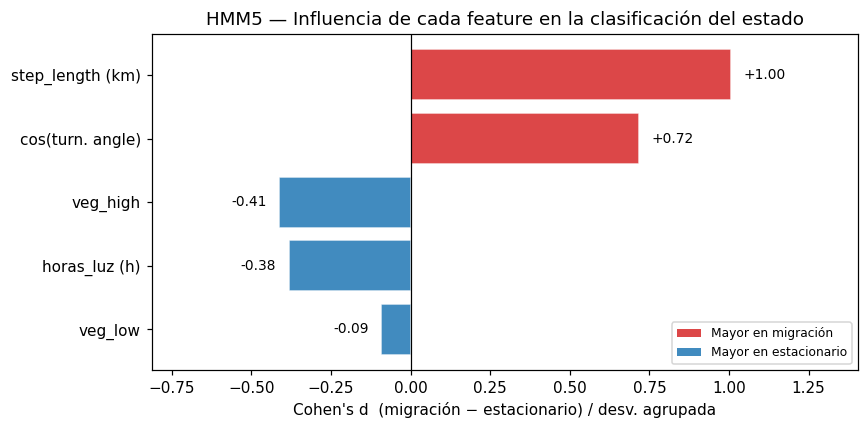


Cohen's d por feature:
  step_length (km)      : d = +1.005  (grande)
  cos(turn. angle)      : d = +0.718  (medio)
  veg_high              : d = -0.413  (pequeño)
  horas_luz (h)         : d = -0.382  (pequeño)
  veg_low               : d = -0.092  (mínimo)


In [14]:
# 8.2 — Influencia de cada feature en la clasificación del estado (Cohen's d)
# Cohen's d = (media_mig − media_est) / desv. estándar agrupada.
# |d| > 0.8 → efecto grande  |d| 0.5–0.8 → medio  |d| 0.2–0.5 → pequeño  |d| < 0.2 → mínimo
feature_cols   = ['step_length', 'cos_turn', 'veg_low', 'veg_high', 'horas_luz']
feature_labels = ['step_length (km)', 'cos(turn. angle)', 'veg_low', 'veg_high', 'horas_luz (h)']

cohens_d = []
for feat in feature_cols:
    mig_v = df_hmm.loc[df_hmm['estado_hmm'] == 0, feat]
    est_v = df_hmm.loc[df_hmm['estado_hmm'] == 1, feat]
    pooled_std = np.sqrt((mig_v.std() ** 2 + est_v.std() ** 2) / 2)
    cohens_d.append((mig_v.mean() - est_v.mean()) / pooled_std)

# Ordenar por valor absoluto (mayor discriminación arriba)
order    = np.argsort(np.abs(cohens_d))
s_labels = [feature_labels[i] for i in order]
s_d      = [cohens_d[i]       for i in order]
colors   = ['tab:red' if d > 0 else 'tab:blue' for d in s_d]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(s_labels, s_d, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Cohen's d  (migración − estacionario) / desv. agrupada")
ax.set_title("HMM5 — Influencia de cada feature en la clasificación del estado")

for bar, d in zip(bars, s_d):
    offset = 0.04 if d >= 0 else -0.04
    ax.text(d + offset, bar.get_y() + bar.get_height() / 2,
            f'{d:+.2f}', va='center',
            ha='left' if d >= 0 else 'right', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='tab:red',  alpha=0.85, label='Mayor en migración'),
    Patch(facecolor='tab:blue', alpha=0.85, label='Mayor en estacionario'),
], loc='lower right', fontsize=8)
ax.set_xlim(min(s_d) - 0.4, max(s_d) + 0.4)
plt.tight_layout()
plt.show()

print("\nCohen's d por feature:")
for lbl, d in sorted(zip(feature_labels, cohens_d), key=lambda x: abs(x[1]), reverse=True):
    nivel = 'grande' if abs(d) > 0.8 else 'medio' if abs(d) > 0.5 else 'pequeño' if abs(d) > 0.2 else 'mínimo'
    print(f'  {lbl:<22s}: d = {d:+.3f}  ({nivel})')

In [15]:
# 8.2 — Matriz de transición y duración media
T = transmat_remapped
T_df = pd.DataFrame(T,
                    index=['desde migración', 'desde estacionario'],
                    columns=['→ migración', '→ estacionario'])
print('Matriz de transición:')
print(T_df.round(4))

mean_dur_mig = 1 / (1 - T[0, 0])
mean_dur_est = 1 / (1 - T[1, 1])
print(f'\nDuración media en migración:  {mean_dur_mig:.2f} días')
print(f'Duración media en estacionario: {mean_dur_est:.2f} días')

Matriz de transición:
                    → migración  → estacionario
desde migración          0.7694          0.2306
desde estacionario       0.0405          0.9595

Duración media en migración:  4.34 días
Duración media en estacionario: 24.70 días


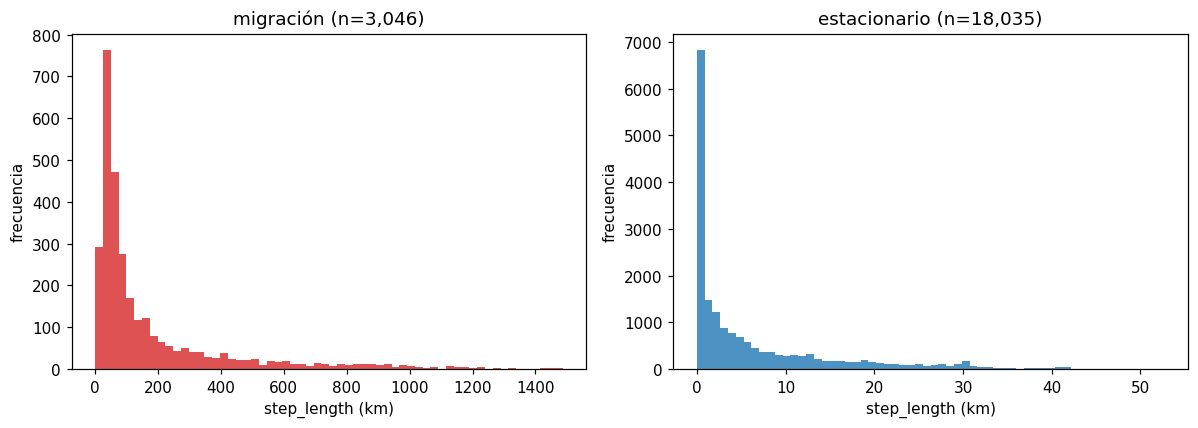

In [16]:
# 8.3 — Histogramas de step_length por estado
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for state, name, ax, color in [(0, 'migración', axes[0], 'tab:red'),
                                (1, 'estacionario', axes[1], 'tab:blue')]:
    sub = df_hmm.loc[df_hmm['estado_hmm'] == state, 'step_length']
    ax.hist(sub, bins=60, color=color, alpha=0.8)
    ax.set_title(f'{name} (n={len(sub):,})')
    ax.set_xlabel('step_length (km)')
    ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

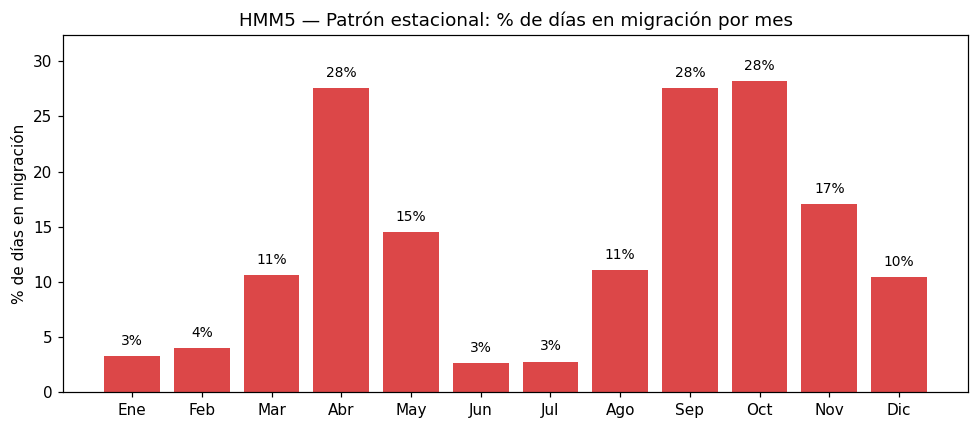


% de días en migración por mes:
mes
1     3.3000
2     4.0000
3    10.7000
4    27.6000
5    14.5000
6     2.7000
7     2.8000
8    11.1000
9    27.6000
10   28.2000
11   17.1000
12   10.5000
Name: estado_hmm, dtype: float64


In [17]:
# 8.4 — Patrón estacional
df_hmm['mes'] = df_hmm['date'].dt.month
pct_mig = df_hmm.groupby('mes')['estado_hmm'].apply(lambda s: (s == 0).mean() * 100)
nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(nombres, pct_mig.values, color='tab:red', alpha=0.85)
ax.set_ylabel('% de días en migración')
ax.set_title('HMM5 — Patrón estacional: % de días en migración por mes')
ax.set_ylim(0, max(pct_mig.values) * 1.15)
for i, v in enumerate(pct_mig.values):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n% de días en migración por mes:')
print(pct_mig.round(1))

In [18]:
# 8.5 — Distribución de migración por bin de step_length
bins = [0, 10, 50, 100, 1e6]
labels = ['<10 km', '10-50 km', '50-100 km', '>100 km']
df_hmm['step_bin'] = pd.cut(df_hmm['step_length'], bins=bins, labels=labels, right=False)
pct_mig_bin = (df_hmm.groupby('step_bin', observed=True)
               .agg(n=('estado_hmm', 'size'),
                    pct_mig=('estado_hmm', lambda s: (s == 0).mean() * 100))
               .round(2))
print('% de días en migración por bin de step_length:')
print(pct_mig_bin)

% de días en migración por bin de step_length:
               n  pct_mig
step_bin                 
<10 km     14154   0.8500
10-50 km    4935  19.1700
50-100 km    757  98.2800
>100 km     1235 100.0000


Ave ejemplo: 91916A (2026 días)


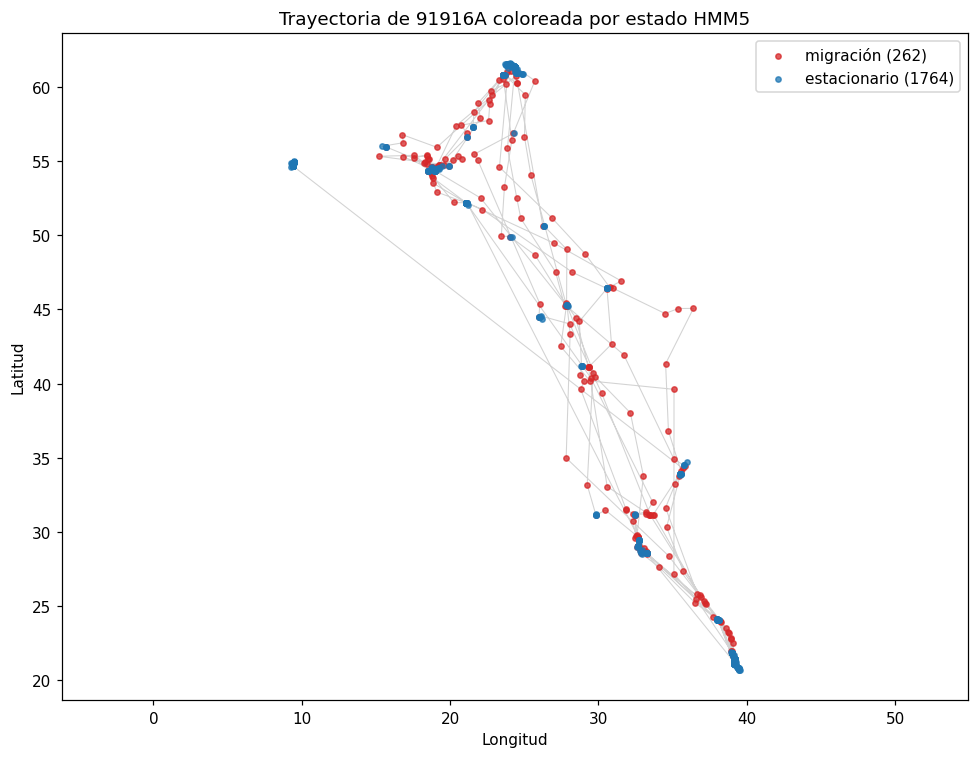

In [19]:
# 8.6 — Trayectoria ejemplo
ave_ej = df_hmm['animal_id'].value_counts().index[0]
sub = df_hmm[df_hmm['animal_id'] == ave_ej].sort_values('date')
print(f'Ave ejemplo: {ave_ej} ({len(sub)} días)')

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(sub['lon'], sub['lat'], color='lightgray', linewidth=0.7, zorder=1)
for state, name, color in [(0, 'migración', 'tab:red'), (1, 'estacionario', 'tab:blue')]:
    pts = sub[sub['estado_hmm'] == state]
    ax.scatter(pts['lon'], pts['lat'], s=12, c=color, label=f'{name} ({len(pts)})',
               alpha=0.75, zorder=2)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Trayectoria de {ave_ej} coloreada por estado HMM5')
ax.legend()
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.show()

## 9. Comparación HMM5 vs HMM2 vs HMM3

Tres preguntas operativas:

1. **¿Ajusta mejor los datos?** → BIC y AIC (penalizan número de parámetros).
2. **¿Cambia las asignaciones respecto a HMM2?** → concordancia día-a-día y matriz de confusión.
3. **¿Las nuevas features discriminan estados?** → diferencia de medias de `horas_luz` y vegetación entre estados.

Para BIC y AIC necesitamos el log-likelihood de los tres modelos. Re-entrenamos HMM2 y HMM3 con la mejor seed para tener `score()` exacto sobre los mismos `lengths` que usamos aquí, y así la comparación es justa.

In [20]:
# 9.1 — Re-entrenamos HMM2 y HMM3 con la misma rutina (15 seeds → mejor LL)
def fit_hmm_best(X_in, lengths_in, seeds=15):
    best = (-np.inf, None, None)
    for seed in range(seeds):
        m = GaussianHMM(n_components=2, covariance_type='diag',
                        n_iter=200, tol=1e-4, random_state=seed)
        m.fit(X_in, lengths=lengths_in)
        s = m.score(X_in, lengths=lengths_in)
        if s > best[0]:
            best = (s, m, seed)
    return best

# HMM2: solo step_length, cos_turn (mismo df_hmm para mantener filas alineadas)
X_hmm2 = df_hmm[['step_length', 'cos_turn']].values
ll_hmm2, model_hmm2, seed_hmm2 = fit_hmm_best(X_hmm2, lengths)
print(f'HMM2 reentrenado (2 features): seed={seed_hmm2}, LL={ll_hmm2:,.1f}')

# HMM3: + veg_low, veg_high
X_hmm3 = df_hmm[['step_length', 'cos_turn', 'veg_low', 'veg_high']].values
ll_hmm3, model_hmm3, seed_hmm3 = fit_hmm_best(X_hmm3, lengths)
print(f'HMM3 reentrenado (4 features): seed={seed_hmm3}, LL={ll_hmm3:,.1f}')

# HMM5: ya entrenado en best_model
ll_hmm5 = best_score
print(f'HMM5 entrenado (5 features):    seed={best_seed}, LL={ll_hmm5:,.1f}')

HMM2 reentrenado (2 features): seed=5, LL=-113,068.9


HMM3 reentrenado (4 features): seed=3, LL=-121,642.2
HMM5 entrenado (5 features):    seed=6, LL=-171,351.2


In [21]:
# 9.2 — Cálculo de BIC y AIC
# Para GaussianHMM con n_components=K y covariance_type='diag' y d features:
#   parámetros = (K-1) start_prob + K*(K-1) transmat + K*d means + K*d covars
#              = (K-1) + K*(K-1) + 2*K*d
def hmm_params(K, d, cov_type='diag'):
    if cov_type != 'diag':
        raise ValueError('Solo soportado diag aquí')
    return (K - 1) + K * (K - 1) + 2 * K * d

n_obs = len(X)  # mismo n para los tres
K = 2

rows = []
for name, ll, d in [('HMM2', ll_hmm2, 2), ('HMM3', ll_hmm3, 4), ('HMM5', ll_hmm5, 5)]:
    k_par = hmm_params(K, d)
    bic = -2 * ll + k_par * np.log(n_obs)
    aic = -2 * ll + 2 * k_par
    rows.append({'modelo': name, 'd_features': d, 'k_params': k_par,
                 'log_likelihood': ll, 'AIC': aic, 'BIC': bic})

bic_df = pd.DataFrame(rows).set_index('modelo')
print('Comparación de modelos por LL, AIC y BIC (n =', n_obs, '):')
print(bic_df.round(1))
print()
best_bic = bic_df['BIC'].idxmin()
best_aic = bic_df['AIC'].idxmin()
print(f'Mejor BIC: {best_bic} (penaliza más el número de parámetros)')
print(f'Mejor AIC: {best_aic}')
print(f'\nΔBIC(HMM5 − HMM2) = {bic_df.loc["HMM5", "BIC"] - bic_df.loc["HMM2", "BIC"]:+,.1f}')
print(f'ΔBIC(HMM5 − HMM3) = {bic_df.loc["HMM5", "BIC"] - bic_df.loc["HMM3", "BIC"]:+,.1f}')
print('Interpretación: ΔBIC < 0 → el modelo más complejo compensa su coste; > 0 → no compensa.')

Comparación de modelos por LL, AIC y BIC (n = 21081 ):
        d_features  k_params  log_likelihood         AIC         BIC
modelo                                                              
HMM2             2        11    -113068.9000 226159.7000 226247.2000
HMM3             4        19    -121642.2000 243322.4000 243473.5000
HMM5             5        23    -171351.2000 342748.4000 342931.4000

Mejor BIC: HMM2 (penaliza más el número de parámetros)
Mejor AIC: HMM2

ΔBIC(HMM5 − HMM2) = +116,684.2
ΔBIC(HMM5 − HMM3) = +99,457.9
Interpretación: ΔBIC < 0 → el modelo más complejo compensa su coste; > 0 → no compensa.


In [22]:
# 9.3 — Concordancia día-a-día con HMM2 y HMM3 (cargando los CSVs guardados)
hmm2_csv = pd.read_csv('../data/processed/hmm2.csv')
hmm2_csv['date'] = pd.to_datetime(hmm2_csv['date'])

hmm3_csv = pd.read_csv('../data/processed/hmm3.csv')
hmm3_csv['date'] = pd.to_datetime(hmm3_csv['date'])

hmm5_now = df_hmm[['animal_id', 'date', 'estado_hmm']].rename(
    columns={'estado_hmm': 'estado_hmm5'})

# Merge con HMM2
merged_2_5 = hmm2_csv[['animal_id', 'date', 'estado_hmm']].rename(
    columns={'estado_hmm': 'estado_hmm2'}
).merge(hmm5_now, on=['animal_id', 'date'], how='inner')
agree_2_5 = (merged_2_5['estado_hmm2'] == merged_2_5['estado_hmm5']).mean()
print(f'Filas alineadas HMM2 ∩ HMM5: {len(merged_2_5):,}')
print(f'% acuerdo HMM5 vs HMM2: {agree_2_5 * 100:.2f}%')
print('\nMatriz de confusión (filas=HMM2, columnas=HMM5):')
cm_25 = pd.crosstab(
    merged_2_5['estado_hmm2'].map({0: 'migración', 1: 'estacionario'}),
    merged_2_5['estado_hmm5'].map({0: 'migración', 1: 'estacionario'}),
    rownames=['HMM2'], colnames=['HMM5'],
)
print(cm_25)

# Merge con HMM3
merged_3_5 = hmm3_csv[['animal_id', 'date', 'estado_hmm']].rename(
    columns={'estado_hmm': 'estado_hmm3'}
).merge(hmm5_now, on=['animal_id', 'date'], how='inner')
agree_3_5 = (merged_3_5['estado_hmm3'] == merged_3_5['estado_hmm5']).mean()
print(f'\n--- HMM3 vs HMM5 ---')
print(f'Filas alineadas HMM3 ∩ HMM5: {len(merged_3_5):,}')
print(f'% acuerdo HMM5 vs HMM3: {agree_3_5 * 100:.2f}%')
print('\nMatriz de confusión (filas=HMM3, columnas=HMM5):')
cm_35 = pd.crosstab(
    merged_3_5['estado_hmm3'].map({0: 'migración', 1: 'estacionario'}),
    merged_3_5['estado_hmm5'].map({0: 'migración', 1: 'estacionario'}),
    rownames=['HMM3'], colnames=['HMM5'],
)
print(cm_35)

Filas alineadas HMM2 ∩ HMM5: 20,836
% acuerdo HMM5 vs HMM2: 86.44%

Matriz de confusión (filas=HMM2, columnas=HMM5):
HMM5          estacionario  migración
HMM2                                 
estacionario         15301         97
migración             2729       2709

--- HMM3 vs HMM5 ---
Filas alineadas HMM3 ∩ HMM5: 21,081
% acuerdo HMM5 vs HMM3: 91.58%

Matriz de confusión (filas=HMM3, columnas=HMM5):
HMM5          estacionario  migración
HMM3                                 
estacionario         16357         98
migración             1678       2948


In [23]:
# 9.4 — Distribución de step_length de los días reclasificados HMM2 → HMM5
# Lo construimos uniendo step_length de hmm5 al merge.
step_for_merge = df_hmm[['animal_id', 'date', 'step_length']].copy()
m25 = merged_2_5.merge(step_for_merge, on=['animal_id', 'date'], how='left')
flips_25 = m25[m25['estado_hmm2'] != m25['estado_hmm5']].copy()
print(f'Días reclasificados entre HMM2 y HMM5: {len(flips_25):,}')
if len(flips_25) > 0:
    print('\nDistribución de step_length de los días reclasificados:')
    print(flips_25['step_length'].describe(percentiles=[.25, .5, .75]).round(2))
    print('\nPor tipo de reclasificación:')
    flips_25['tipo'] = np.where(flips_25['estado_hmm2'] == 1, 'est→mig', 'mig→est')
    print(flips_25.groupby('tipo')['step_length'].agg(['count', 'mean', 'median']).round(2))

Días reclasificados entre HMM2 y HMM5: 2,826

Distribución de step_length de los días reclasificados:
count   2826.0000
mean      22.8400
std        8.6800
min        0.0000
25%       17.4300
50%       21.6800
75%       28.7000
max       52.7200
Name: step_length, dtype: float64

Por tipo de reclasificación:
         count    mean  median
tipo                          
est→mig     97  2.4300  1.5700
mig→est   2729 23.5600 22.1400


In [24]:
# 9.5 — Test estadístico: ¿horas_luz difiere entre estados?
from scipy.stats import mannwhitneyu

luz_mig = df_hmm.loc[df_hmm['estado_hmm'] == 0, 'horas_luz']
luz_est = df_hmm.loc[df_hmm['estado_hmm'] == 1, 'horas_luz']

u_stat, p_value = mannwhitneyu(luz_mig, luz_est, alternative='two-sided')
print('Test Mann-Whitney U: ¿la distribución de horas_luz difiere entre migración y estacionario?')
print(f'  Migración:   n={len(luz_mig):,}, media={luz_mig.mean():.2f} h, mediana={luz_mig.median():.2f} h')
print(f'  Estacionario: n={len(luz_est):,}, media={luz_est.mean():.2f} h, mediana={luz_est.median():.2f} h')
print(f'  Δ medias = {luz_mig.mean() - luz_est.mean():+.2f} h')
print(f'  U = {u_stat:,.0f}, p-value = {p_value:.2e}')
print('\nLectura: con n muy grande casi cualquier diferencia es estadísticamente')
print('significativa; lo importante es la magnitud de Δ medias en horas reales.')

Test Mann-Whitney U: ¿la distribución de horas_luz difiere entre migración y estacionario?
  Migración:   n=3,046, media=12.43 h, mediana=12.03 h
  Estacionario: n=18,035, media=13.26 h, mediana=12.06 h
  Δ medias = -0.83 h
  U = 24,439,056, p-value = 1.89e-22

Lectura: con n muy grande casi cualquier diferencia es estadísticamente
significativa; lo importante es la magnitud de Δ medias en horas reales.


In [25]:
# 9.6 — Tabla resumen final HMM2 vs HMM3 vs HMM5
def stats_block(df_csv, label):
    s = (df_csv.groupby('estado_hmm')['step_length']
         .agg(['mean', 'median']).round(2))
    return {
        f'{label} step mig (km)':  s.loc[0, 'mean'],
        f'{label} step est (km)':  s.loc[1, 'mean'],
        f'{label} %mig':           (df_csv['estado_hmm'] == 0).mean() * 100,
    }

# Persistencias
def persistence(model, mig_state):
    perm = [mig_state, 1 - mig_state]
    T = model.transmat_[perm][:, perm]
    return T[0, 0], T[1, 1]

# Para HMM2 y HMM3 reentrenados aquí
def find_mig_state(model):
    return int(np.argmax(model.means_[:, 0]))

p_mig_2, p_est_2 = persistence(model_hmm2, find_mig_state(model_hmm2))
p_mig_3, p_est_3 = persistence(model_hmm3, find_mig_state(model_hmm3))
p_mig_5, p_est_5 = T[0, 0], T[1, 1]

resumen = pd.DataFrame([
    ['LL (train)', f'{ll_hmm2:,.1f}', f'{ll_hmm3:,.1f}', f'{ll_hmm5:,.1f}'],
    ['nº parámetros', hmm_params(2, 2), hmm_params(2, 4), hmm_params(2, 5)],
    ['BIC', f'{bic_df.loc["HMM2", "BIC"]:,.1f}', f'{bic_df.loc["HMM3", "BIC"]:,.1f}', f'{bic_df.loc["HMM5", "BIC"]:,.1f}'],
    ['AIC', f'{bic_df.loc["HMM2", "AIC"]:,.1f}', f'{bic_df.loc["HMM3", "AIC"]:,.1f}', f'{bic_df.loc["HMM5", "AIC"]:,.1f}'],
    ['% días migración',
     f'{(hmm2_csv["estado_hmm"] == 0).mean() * 100:.2f}%',
     f'{(hmm3_csv["estado_hmm"] == 0).mean() * 100:.2f}%',
     f'{(df_hmm["estado_hmm"] == 0).mean() * 100:.2f}%'],
    ['Persistencia mig (p_diag)', f'{p_mig_2:.3f}', f'{p_mig_3:.3f}', f'{p_mig_5:.3f}'],
    ['Persistencia est (p_diag)', f'{p_est_2:.3f}', f'{p_est_3:.3f}', f'{p_est_5:.3f}'],
    ['Duración media est (días)',
     f'{1/(1-p_est_2):.2f}', f'{1/(1-p_est_3):.2f}', f'{1/(1-p_est_5):.2f}'],
    ['Concordancia con HMM2', '100.00%', f'{(hmm2_csv.merge(hmm3_csv, on=["animal_id","date"], suffixes=("_2","_3"))["estado_hmm_2"] == hmm2_csv.merge(hmm3_csv, on=["animal_id","date"], suffixes=("_2","_3"))["estado_hmm_3"]).mean() * 100:.2f}%', f'{agree_2_5 * 100:.2f}%'],
], columns=['métrica', 'HMM2', 'HMM3', 'HMM5']).set_index('métrica')

print('Resumen comparativo HMM2 / HMM3 / HMM5:')
print(resumen.to_string())

Resumen comparativo HMM2 / HMM3 / HMM5:
                                 HMM2        HMM3        HMM5
métrica                                                      
LL (train)                 -113,068.9  -121,642.2  -171,351.2
nº parámetros                      11          19          23
BIC                         226,247.2   243,473.5   342,931.4
AIC                         226,159.7   243,322.4   342,748.4
% días migración               26.10%      21.94%      14.45%
Persistencia mig (p_diag)       0.706       0.715       0.769
Persistencia est (p_diag)       0.917       0.917       0.960
Duración media est (días)       12.10       12.00       24.70
Concordancia con HMM2         100.00%      94.49%      86.44%


## Conclusión

Las preguntas operativas a resolver con los números de las celdas anteriores:

1. **¿BIC favorece a HMM5?** Si ΔBIC(HMM5−HMM2) < 0 las features añadidas compensan; si > 0 no. Recordar que BIC penaliza fuerte (log n ≈ 10).
2. **¿La concordancia con HMM2 supera el 95 %?** Si sí, HMM5 es una variante leve (como HMM3). Si no, hay reasignaciones reales que conviene inspeccionar (sección 9.4).
3. **¿`horas_luz` discrimina estados?** Si Δ medias entre mig y est es > 2 h y se concentra en valores predecibles biológicamente (p. ej. mig en días largos por migración estival, est en días cortos por invernada), hay señal real. Si Δ < 1 h, la fotoperiodía no aporta valor de comportamiento al HMM con `covariance_type='diag'` y `step_length` sin escalar.
4. **¿Persistencia y patrón estacional siguen coherentes?** La persistencia diagonal de estacionario debería seguir > 0,9 y el patrón estacional debería mostrar valle en enero / pico en abril y septiembre.

Con la respuesta numérica, la decisión de qué versión usar como output canónico para los modelos ML downstream es directa: BIC mínimo + concordancia razonable + estructura temporal coherente.